In [1]:
import tensorflow as tf 
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

In [2]:
texts = [
    "The tire degradation strategy was executed perfectly.",
    "Unsafe release in the pit lane ruined everything.",
    "The new aerodynamic upgrades are working flawlessly.",
    "Incredible podium finish for the team today.",
    "The pit stop was unbelievably fast.",
    "Brilliant defensive driving to hold position.",
    "The engine failed right in the middle of the straight.",
    "Terrible strategy call cost them the race.",
    "The car lacks pure straight-line speed.",
    "Another frustrating DNF this weekend.",
    "The tire wear is absolutely awful.",
    "Amazing overtake on the final lap!"
]

labels = np.array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1])

In [3]:
tokens = []
for i in texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    tokens.append(words)

print(tokens)

[['the', 'tire', 'degradation', 'strategy', 'was', 'executed', 'perfectly'], ['unsafe', 'release', 'in', 'the', 'pit', 'lane', 'ruined', 'everything'], ['the', 'new', 'aerodynamic', 'upgrades', 'are', 'working', 'flawlessly'], ['incredible', 'podium', 'finish', 'for', 'the', 'team', 'today'], ['the', 'pit', 'stop', 'was', 'unbelievably', 'fast'], ['brilliant', 'defensive', 'driving', 'to', 'hold', 'position'], ['the', 'engine', 'failed', 'right', 'in', 'the', 'middle', 'of', 'the', 'straight'], ['terrible', 'strategy', 'call', 'cost', 'them', 'the', 'race'], ['the', 'car', 'lacks', 'pure', 'straightline', 'speed'], ['another', 'frustrating', 'dnf', 'this', 'weekend'], ['the', 'tire', 'wear', 'is', 'absolutely', 'awful'], ['amazing', 'overtake', 'on', 'the', 'final', 'lap']]


In [4]:
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)


In [5]:
sentence_vectors = []

for sentence in tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)
    sentence_vectors.append(sentence_vector)

X_word = np.array(sentence_vectors)

print(X_word.shape)

(12, 50)


In [6]:
model2 = Sequential()
model2.add(Dense(8,activation = 'relu', input_shape = (X_word.shape[1],)))
model2.add(Dense(1,activation = 'sigmoid'))

c:\Users\mohit\Documents\NLP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model2.fit(X_word,labels,epochs=15,verbose=0)
loss, accuracy = model2.evaluate(X_word, labels)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.6667 - loss: 0.6914
Accuracy: 0.6666666865348816


In [9]:
new_texts = [
    "The new suspension updates feel amazing on the track."]

new_tokens = []
for i in new_texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    new_tokens.append(words)

print(new_tokens)




[['the', 'new', 'suspension', 'updates', 'feel', 'amazing', 'on', 'the', 'track']]


In [10]:
word_model.build_vocab(new_tokens, update=True)

word_model.train(
    new_tokens,
    total_examples=len(new_tokens),
    epochs=15
)

new_sentence_vectors = []

for sentence in new_tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    new_sentence_vector = np.mean(word_vectors, axis=0)
    new_sentence_vectors.append(new_sentence_vector)

new_word = np.array(new_sentence_vectors)

print(new_word.shape)

(1, 50)


In [11]:
predictions = model2.predict(new_word)
print("Predicted probabilities for new texts:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicted probabilities for new texts:
[[0.5002081]]


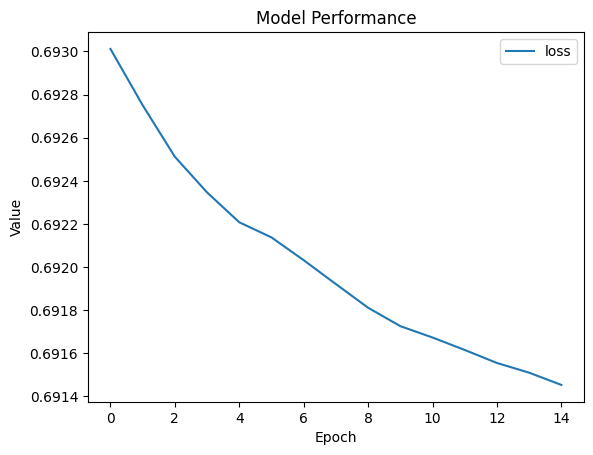

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()